## gwModelRemPE : remnant properties of eccentric precessing BBH mergers

`gwModelRemPE` applies the `gwModelRemSE` eccentric corrections on top of the
precessing quasi-circular baseline `gwModelRemP`. Inputs are the seven
precessing-spin parameters at $r = 8M$ plus $(e_{\rm ref}, \ell_{\rm ref})$
at $t = -2500M$:

$$M_f = M_f^{\rm P}\left[1 + \delta_M\right], \quad
|\chi_f| = |\chi_f|^{\rm P}\left[1 + \delta_\chi\right], \quad
L_{\rm peak} = L_{\rm peak}^{\rm P}\left[1 + \delta_L\right]$$

The correction factors are exactly those of `gwModelRemSE`, reusing its 28
calibrated coefficients unchanged; only the baseline differs. $\theta_f$ carries
no eccentric correction, because none was calibrated for the spin direction.

> **Note.** The eccentric corrections were calibrated on non-spinning
> aligned-spin systems and are applied here to a precessing baseline,
> treating the two effects as independent at leading order. The
> factorization has not been checked against precessing eccentric NR.
> All `gwModelRemSE` caveats carry over in full.

In [1]:
import sys
!{sys.executable} -m pip install -e ../ --no-deps --quiet

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import gwModels
gwModels.utils.set_rcparams()

lal.MSUN_SI != Msun


### 1. Basic evaluation

In [2]:
q = 2.0
a1, a2 = 0.7, 0.3
theta1, theta2 = np.pi / 3, np.pi / 4
phi1, phi2 = 0.0, 0.0
e_ref, l_ref = 0.15, 0.5

Mf, af, theta_f, Lpeak = gwModels.remnants.gwModelRemPE(
    q, a1, a2, theta1, theta2, phi1, phi2, e_ref, l_ref)

print(f'q = {q}, a1 = {a1}, a2 = {a2}')
print(f'theta1 = {np.degrees(theta1):.1f} deg, theta2 = {np.degrees(theta2):.1f} deg')
print(f'e_ref = {e_ref}, l_ref = {l_ref}')
print()
print(f'  Mf/M           = {Mf:.6f}')
print(f'  |chi_f|        = {af:.6f}')
print(f'  theta_f        = {np.degrees(theta_f):.3f} deg')
print(f'  L_peak [c^5/G] = {Lpeak:.6e}')

q = 2.0, a1 = 0.7, a2 = 0.3
theta1 = 60.0 deg, theta2 = 45.0 deg
e_ref = 0.15, l_ref = 0.5

  Mf/M           = 0.950938
  |chi_f|        = 0.767445
  theta_f        = 16.596 deg
  L_peak [c^5/G] = 9.745464e-04


### 2. Three exact limits\n\n`gwModelRemPE` sits at the top of the model hierarchy and collapses onto each of the simpler models exactly:\n\n| Limit | Reduces to |\n|---|---|\n| $e_{\rm ref} \to 0$ | `gwModelRemP` |\n| $S_\perp, \Delta_\perp \to 0$ | `gwModelRemSE` |\n| both $\to 0$ | `gwModelRemS` |

In [3]:
args = (2.0, 0.7, 0.3, np.pi / 3, np.pi / 4, 0.0, 0.0)

# (a) circular limit -> gwModelRemP
pe = gwModels.remnants.gwModelRemPE(*args, 0.0, 0.0)
p = gwModels.remnants.gwModelRemP(*args)
print('(a) e_ref = 0  ->  gwModelRemP')
for lab, x, y in zip(['Mf', '|chif|', 'theta_f', 'Lpeak'], pe, p):
    print(f'      {lab:>8s} : {x:.15g}   exact: {x == y}')

# (b) aligned limit -> gwModelRemSE
pe = gwModels.remnants.gwModelRemPE(3.0, 0.5, 0.3, 0.0, np.pi, 0.0, 0.0, 0.15, 1.0)
se = gwModels.remnants.gwModelRemSE(3.0, 0.5, -0.3, 0.15, 1.0)
print()
print('(b) S_perp = 0  ->  gwModelRemSE')
print(f'      {"Mf":>8s} : {pe[0]:.15g}   exact: {pe[0] == se[0]}')
print(f'      {"|chif|":>8s} : {pe[1]:.15g}   exact: {pe[1] == abs(se[1])}')
print(f'      {"Lpeak":>8s} : {pe[3]:.6e}   exact: {pe[3] == se[3]}')

# (c) both -> gwModelRemS
pe = gwModels.remnants.gwModelRemPE(3.0, 0.5, 0.3, 0.0, np.pi, 0.0, 0.0, 0.0, 0.0)
s = gwModels.remnants.gwModelRemS(3.0, 0.5, -0.3)
print()
print('(c) both = 0   ->  gwModelRemS')
print(f'      {"Mf":>8s} : {pe[0]:.15g}   exact: {pe[0] == s[0]}')
print(f'      {"|chif|":>8s} : {pe[1]:.15g}   exact: {pe[1] == abs(s[1])}')
print(f'      {"Lpeak":>8s} : {pe[3]:.6e}   exact: {pe[3] == s[2]}')

(a) e_ref = 0  ->  gwModelRemP
            Mf : 0.950969639769612   exact: True
        |chif| : 0.767568442843936   exact: True
       theta_f : 0.289650458884348   exact: True
         Lpeak : 0.000976734584643093   exact: True

(b) S_perp = 0  ->  gwModelRemSE
            Mf : 0.961799870268308   exact: True
        |chif| : 0.745566863956656   exact: True
         Lpeak : 6.896183e-04   exact: True

(c) both = 0   ->  gwModelRemS
            Mf : 0.961686984172706   exact: True
        |chif| : 0.74663539485805   exact: True
         Lpeak : 6.939919e-04   exact: True


### 3. Eccentricity and precession together

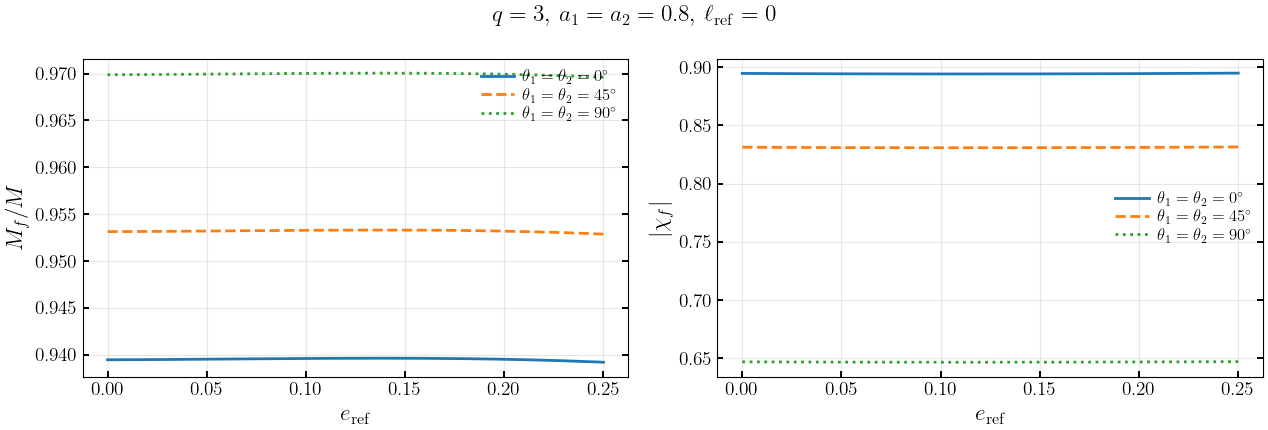

In [4]:
# Eccentric correction on top of several spin tilts
e_arr = np.linspace(0, 0.25, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for tilt, ls in [(0.0, '-'), (np.pi / 4, '--'), (np.pi / 2, ':')]:
    Mf, af, thf, Lp = gwModels.remnants.gwModelRemPE(
        3.0, 0.8, 0.8, tilt, tilt, 0.0, 0.0, e_arr, 0.0)
    lab = rf'$\theta_1=\theta_2={np.degrees(tilt):.0f}^\circ$'
    axes[0].plot(e_arr, Mf, ls, lw=2, label=lab)
    axes[1].plot(e_arr, af, ls, lw=2, label=lab)

axes[0].set_ylabel('$M_f/M$')
axes[1].set_ylabel(r'$|\chi_f|$')
for ax in axes:
    ax.set_xlabel(r'$e_{\rm ref}$')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.suptitle(r'$q=3$, $a_1=a_2=0.8$, $\ell_{\rm ref}=0$')
plt.tight_layout()
plt.show()

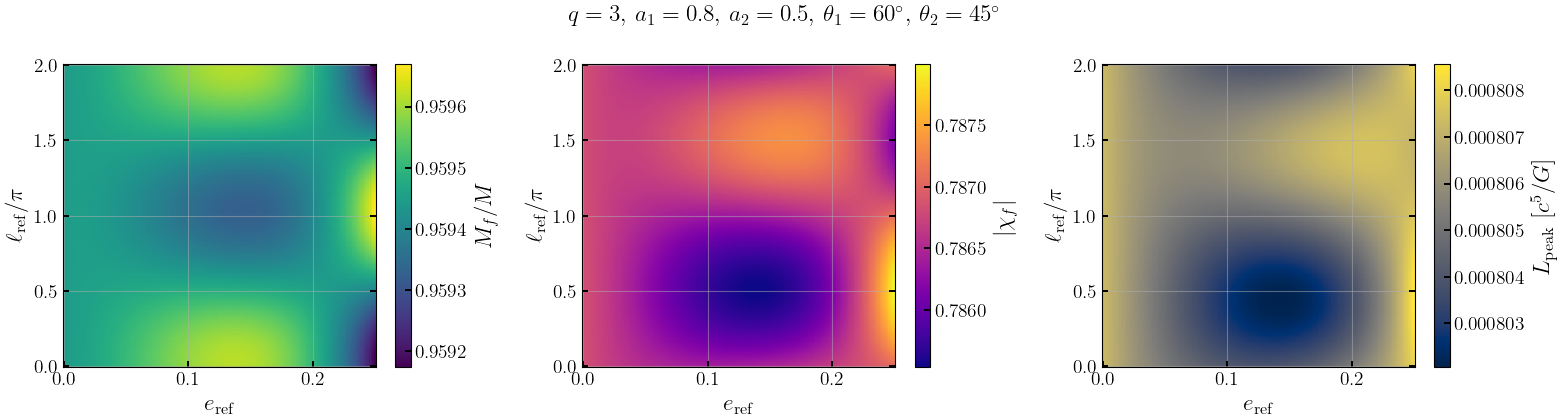

In [5]:
# Two-dimensional map over (e_ref, l_ref) at fixed precessing configuration
e_g = np.linspace(0, 0.25, 180)
l_g = np.linspace(0, 2 * np.pi, 180)
E, L = np.meshgrid(e_g, l_g)

MF, AF, THF, LP = gwModels.remnants.gwModelRemPE(
    3.0, 0.8, 0.5, np.pi / 3, np.pi / 4, 0.0, 0.0, E, L)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, Z, lab, cmap in [
    (axes[0], MF, '$M_f/M$', 'viridis'),
    (axes[1], AF, r'$|\chi_f|$', 'plasma'),
    (axes[2], LP, r'$L_{\rm peak}$ [$c^5/G$]', 'cividis'),
]:
    im = ax.pcolormesh(E, L / np.pi, Z, shading='auto', cmap=cmap)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(lab)
    ax.set_xlabel(r'$e_{\rm ref}$')
    ax.set_ylabel(r'$\ell_{\rm ref}/\pi$')

plt.suptitle(r'$q=3$, $a_1=0.8$, $a_2=0.5$, $\theta_1=60^\circ$, $\theta_2=45^\circ$')
plt.tight_layout()
plt.show()

In [6]:
# theta_f is deliberately left uncorrected: it depends only on the
# precessing baseline, not on eccentricity
for e in [0.0, 0.1, 0.2, 0.25]:
    pe = gwModels.remnants.gwModelRemPE(*args, e, 0.7)
    print(f'  e_ref = {e:.2f} :  theta_f = {np.degrees(pe[2]):.9f} deg')
print()
print('  identical by construction; no eccentric correction was calibrated')
print('  for the remnant spin direction.')

  e_ref = 0.00 :  theta_f = 16.595748828 deg
  e_ref = 0.10 :  theta_f = 16.595748828 deg
  e_ref = 0.20 :  theta_f = 16.595748828 deg
  e_ref = 0.25 :  theta_f = 16.595748828 deg

  identical by construction; no eccentric correction was calibrated
  for the remnant spin direction.


### 4. The model hierarchy side by side\n\nComparing the four deterministic models on the same binary shows how each ingredient contributes.

In [7]:
q_h = 3.0
a1_h, a2_h = 0.8, 0.5
th1_h, th2_h = np.pi / 3, np.pi / 4
e_h, l_h = 0.2, 0.5

c1z = a1_h * np.cos(th1_h)
c2z = a2_h * np.cos(th2_h)

rows = []
s = gwModels.remnants.gwModelRemS(q_h, c1z, c2z)
rows.append(('gwModelRemS  (circular, aligned)', s[0], abs(s[1]), s[2]))

p = gwModels.remnants.gwModelRemP(q_h, a1_h, a2_h, th1_h, th2_h, 0.0, 0.0)
rows.append(('gwModelRemP  (circular, precessing)', p[0], p[1], p[3]))

se = gwModels.remnants.gwModelRemSE(q_h, c1z, c2z, e_h, l_h)
rows.append(('gwModelRemSE (eccentric, aligned)', se[0], abs(se[1]), se[3]))

pe = gwModels.remnants.gwModelRemPE(q_h, a1_h, a2_h, th1_h, th2_h, 0.0, 0.0, e_h, l_h)
rows.append(('gwModelRemPE (eccentric, precessing)', pe[0], pe[1], pe[3]))

print(f'{'model':<38s} {'Mf/M':>10s} {'|chi_f|':>10s} {'L_peak':>13s}')
for name, mf, af, lp in rows:
    print(f'{name:<38s} {mf:10.6f} {af:10.6f} {lp:13.6e}')

model                                        Mf/M    |chi_f|        L_peak
gwModelRemS  (circular, aligned)         0.962236   0.723191  6.759573e-04
gwModelRemP  (circular, precessing)      0.959445   0.786833  8.073355e-04
gwModelRemSE (eccentric, aligned)        0.962287   0.722833  6.735003e-04
gwModelRemPE (eccentric, precessing)     0.959496   0.786444  8.044009e-04


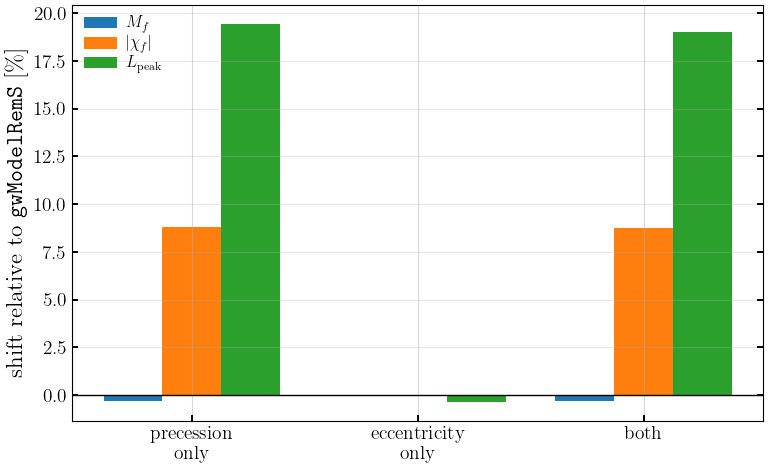

In [8]:
# Relative shift each ingredient produces, using gwModelRemS as reference
labels = ['precession\nonly', 'eccentricity\nonly', 'both']
mf_ref, af_ref, lp_ref = rows[0][1], rows[0][2], rows[0][3]

dmf = [(r[1] - mf_ref) / mf_ref * 100 for r in rows[1:]]
daf = [(r[2] - af_ref) / af_ref * 100 for r in rows[1:]]
dlp = [(r[3] - lp_ref) / lp_ref * 100 for r in rows[1:]]

x = np.arange(3)
w = 0.26

plt.figure(figsize=(8, 5))
plt.bar(x - w, dmf, w, label='$M_f$')
plt.bar(x, daf, w, label=r'$|\chi_f|$')
plt.bar(x + w, dlp, w, label=r'$L_{\rm peak}$')
plt.axhline(0, color='k', lw=1)
plt.xticks(x, labels)
plt.ylabel(r'shift relative to \texttt{gwModelRemS} [\%]')
plt.legend(frameon=False)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5. Recoil\n\n`gwModelRemPE` provides no deterministic recoil, for the same reason `gwModelRemP` does not: the precessing kick depends strongly on the spin azimuths. Use `gwModelRemP_flow` (notebook 6_5) for the distribution, optionally rescaled by the `gwModelRemSE` recoil factor to fold in eccentricity.

In [9]:
# Eccentric rescaling factor for the recoil, from gwModelRemSE
q_r = 3.0
e_r, l_r = 0.2, 0.5

vk_circ = gwModels.remnants.gwModelRemS_kick(q_r, 0.4, 0.3)
vk_ecc = gwModels.remnants.gwModelRemSE_kick(q_r, 0.4, 0.3, e_r, l_r)
factor = vk_ecc / vk_circ

print(f'  circular recoil   : {vk_circ:.4f} km/s')
print(f'  eccentric recoil  : {vk_ecc:.4f} km/s')
print(f'  rescaling factor  : {factor:.6f}')
print()
print('  The same factor can be applied to gwModelRemP_flow samples if an')
print('  eccentric precessing recoil distribution is needed.')

  circular recoil   : 96.8749 km/s
  eccentric recoil  : 96.6343 km/s
  rescaling factor  : 0.997517

  The same factor can be applied to gwModelRemP_flow samples if an
  eccentric precessing recoil distribution is needed.


### 6. Timing

In [10]:
sizes = [1, 10, 100, 1000, 10000, 100000]
means = []

for n in sizes:
    q_t = np.random.uniform(1, 4, n)
    a1_t = np.random.uniform(0, 1, n)
    a2_t = np.random.uniform(0, 1, n)
    t1_t = np.random.uniform(0, np.pi, n)
    t2_t = np.random.uniform(0, np.pi, n)
    e_t = np.random.uniform(0, 0.25, n)
    l_t = np.random.uniform(0, 2 * np.pi, n)
    reps = 20 if n <= 10000 else 5
    t = []
    for _ in range(reps):
        t0 = time.perf_counter()
        gwModels.remnants.gwModelRemPE(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0, e_t, l_t)
        t.append(time.perf_counter() - t0)
    means.append(np.mean(t))

means = np.array(means)
print(f'{'N':>8s}  {'time':>10s}  {'per binary':>13s}')
for n, m in zip(sizes, means):
    print(f'{n:>8d}  {m*1e3:8.3f} ms  {m/n*1e6:10.4f} us')

       N        time     per binary
       1     0.218 ms    218.2125 us
      10     0.211 ms     21.1031 us
     100     0.242 ms      2.4159 us
    1000     0.478 ms      0.4780 us
   10000     3.044 ms      0.3044 us
  100000    31.806 ms      0.3181 us


    gwModelRemS :   6.262 ms


    gwModelRemP :   5.400 ms


   gwModelRemSE :   6.742 ms


   gwModelRemPE :   6.154 ms


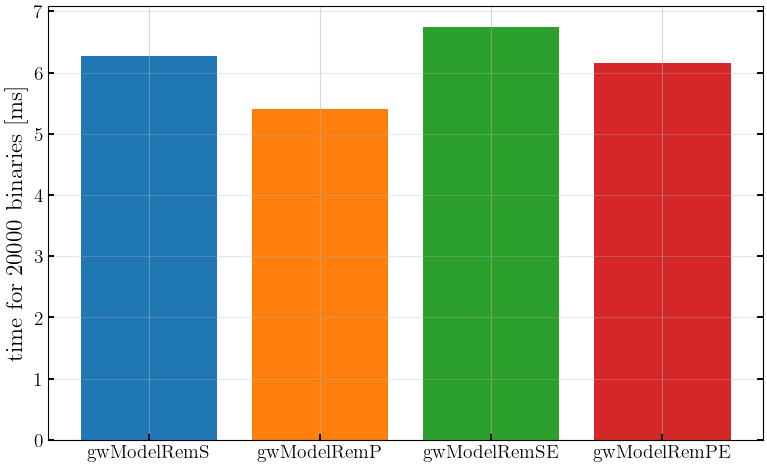

In [11]:
# Cost of the whole hierarchy, 20000 binaries each
n = 20000
q_t = np.random.uniform(1, 4, n)
a1_t = np.random.uniform(0, 1, n)
a2_t = np.random.uniform(0, 1, n)
t1_t = np.random.uniform(0, np.pi, n)
t2_t = np.random.uniform(0, np.pi, n)
c1_t = a1_t * np.cos(t1_t)
c2_t = a2_t * np.cos(t2_t)
e_t = np.random.uniform(0, 0.25, n)
l_t = np.random.uniform(0, 2 * np.pi, n)

names, times = [], []
for name, fn in [
    ('gwModelRemS', lambda: gwModels.remnants.gwModelRemS(q_t, c1_t, c2_t)),
    ('gwModelRemP', lambda: gwModels.remnants.gwModelRemP(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0)),
    ('gwModelRemSE', lambda: gwModels.remnants.gwModelRemSE(q_t, c1_t, c2_t, e_t, l_t)),
    ('gwModelRemPE', lambda: gwModels.remnants.gwModelRemPE(q_t, a1_t, a2_t, t1_t, t2_t, 0.0, 0.0, e_t, l_t)),
]:
    t = []
    for _ in range(20):
        t0 = time.perf_counter()
        fn()
        t.append(time.perf_counter() - t0)
    names.append(name)
    times.append(np.mean(t) * 1e3)
    print(f'  {name:>13s} : {np.mean(t)*1e3:7.3f} ms')

plt.figure(figsize=(8, 5))
plt.bar(names, times, color=['C0', 'C1', 'C2', 'C3'])
plt.ylabel(f'time for {n} binaries [ms]')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()